# Feature Selection Benchmark

Ноутбук для classifier-only benchmark по мотивам секции `5.2 Feature Selection Study` из *How Important Is a Neuron?*. Он сравнивает `IG`, `NAA` и один фиксированный вариант `Cheap-IG` по тому, насколько хорошие `filter/channel`-подмножества они выбирают для простого линейного классификатора.

Текущая постановка:
- модель: `yolo11s-cls`
- слой: `model.6`
- methods: `IG`, `NAA`, `Cheap-IG+[0,0.1]/k8000/zero`
- unit: `filter/channel`
- class aggregation: `positive_mean`
- selection rule: `max_over_classes`
- probe: `StandardScaler + multinomial LogisticRegression`
- default split: `10 train / 10 eval` на класс
- default tasks: `cats_a`, `cats_b`, `dogs_a`, `dogs_b`


## Импорты

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from modules.feature_selection_benchmark import (
    benchmark_classifier_feature_selection,
    default_classifier_method_specs,
    default_feature_selection_tasks,
    render_feature_selection_report,
)


## Параметры

In [2]:
OXFORD_PETS_DIR = Path("oxford_pets")
N_STEPS = 128
TRAIN_PER_CLASS = 10
EVAL_PER_CLASS = 10
K_VALUES = [4, 8, 16, 32, 64]
CHANNEL_AGGREGATION = "positive_mean"
SELECTION_RULE = "max_over_classes"
RANDOM_SEED = 0
CLEAR_EVERY = 8
FD_EPS = 1e-3

CACHE_ROOT = Path("output/feature_selection_cache")
OUTPUT_DIR = Path("output/feature_selection_classifier_oxford_pets")
REFRESH_CORE = False
REFRESH_METHODS = False


## Датасет

In [3]:
def collect_image_paths(root: Path):
    exts = {".jpg", ".jpeg", ".png", ".webp"}
    return sorted(
        [str(path) for path in root.iterdir() if path.suffix.lower() in exts],
        key=lambda path: Path(path).name.lower(),
    )


IMAGE_PATHS = collect_image_paths(OXFORD_PETS_DIR)
len(IMAGE_PATHS), IMAGE_PATHS[:3]


(735,
 ['oxford_pets/Abyssinian_1.jpg',
  'oxford_pets/Abyssinian_108.jpg',
  'oxford_pets/Abyssinian_117.jpg'])

## Tasks

In [4]:
CLASS_TASKS = default_feature_selection_tasks(IMAGE_PATHS)
CLASS_TASKS


[{'name': 'cats_a',
  'classes': ['Abyssinian',
   'Bengal',
   'Birman',
   'British_Shorthair',
   'Maine_Coon']},
 {'name': 'cats_b',
  'classes': ['Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx']},
 {'name': 'dogs_a',
  'classes': ['american_bulldog',
   'american_pit_bull_terrier',
   'basset_hound',
   'beagle',
   'chihuahua']},
 {'name': 'dogs_b',
  'classes': ['english_cocker_spaniel',
   'english_setter',
   'german_shorthaired',
   'great_pyrenees',
   'havanese']}]

## Методы

In [5]:
METHOD_SPECS = default_classifier_method_specs()
METHOD_SPECS


[{'kind': 'ig', 'segment_start': 0.0, 'segment_end': 1.0, 'name': 'IG'},
 {'kind': 'naa', 'segment_start': 0.0, 'segment_end': 1.0, 'name': 'NAA'},
 {'kind': 'cheap_ig',
  'segment_start': 0.0,
  'segment_end': 0.1,
  'selection_mode': 'positive',
  'selection_top_k': 8000,
  'fill_mode': 'zero',
  'fill_rho': 0.8,
  'name': 'Cheap-IG+[0,0.1]/k8000/zero'}]

## Запуск Benchmark

In [6]:
results = benchmark_classifier_feature_selection(
    image_paths=IMAGE_PATHS,
    method_specs=METHOD_SPECS,
    class_tasks=CLASS_TASKS,
    layer_name="model.6",
    n_steps=N_STEPS,
    train_per_class=TRAIN_PER_CLASS,
    eval_per_class=EVAL_PER_CLASS,
    k_values=K_VALUES,
    channel_aggregation=CHANNEL_AGGREGATION,
    selection_rule=SELECTION_RULE,
    random_seed=RANDOM_SEED,
    cache_root=CACHE_ROOT,
    target_dir=OUTPUT_DIR,
    save_output=True,
    top_n=0,
    fd_eps=FD_EPS,
    clear_every=CLEAR_EVERY,
    refresh_core=REFRESH_CORE,
    refresh_methods=REFRESH_METHODS,
)

print("output_dir:", results["output_dir"])
print("report_path:", results["report_path"])
print("summary_path:", results["summary_path"])


output_dir: /Users/ashentide/PycharmProjects/PaperImplementations/output/feature_selection_classifier_oxford_pets
report_path: /Users/ashentide/PycharmProjects/PaperImplementations/output/feature_selection_classifier_oxford_pets/feature_selection_report.md
summary_path: /Users/ashentide/PycharmProjects/PaperImplementations/output/feature_selection_classifier_oxford_pets/feature_selection_summary.json


## Перерисовка отчёта

In [7]:
artifacts = render_feature_selection_report(results, output_dir=OUTPUT_DIR)
artifacts["report_path"], artifacts["summary_path"]


('output/feature_selection_classifier_oxford_pets/feature_selection_report.md',
 'output/feature_selection_classifier_oxford_pets/feature_selection_summary.json')

## Markdown-отчёт

In [8]:
display(Markdown(Path(artifacts["report_path"]).read_text(encoding="utf-8")))


# Feature Selection Benchmark

Classifier-only feature-selection benchmark inspired by Sec. 5.2 of *How Important Is a Neuron?*.

## Configuration

- layer_name=`model.6`
- n_steps=`128`
- train_per_class=`10`
- eval_per_class=`10`
- k_values=`[4, 8, 16, 32, 64]`
- channel_aggregation=`positive_mean`
- selection_rule=`max_over_classes`
- random_seed=`0`

## Tasks

| Task | Classes |
| --- | --- |
| cats_a | Abyssinian, Bengal, Birman, British_Shorthair, Maine_Coon |
| cats_b | Persian, Ragdoll, Russian_Blue, Siamese, Sphynx |
| dogs_a | american_bulldog, american_pit_bull_terrier, basset_hound, beagle, chihuahua |
| dogs_b | english_cocker_spaniel, english_setter, german_shorthaired, great_pyrenees, havanese |

## Best-k Summary

| Method | Best k | Mean accuracy | Mean macro-F1 |
| --- | ---: | ---: | ---: |
| IG | 64 | 0.6550 | 0.6491 |
| NAA | 64 | 0.6300 | 0.6267 |
| Cheap-IG+[0,0.1]/k8000/zero | 64 | 0.6750 | 0.6719 |

## Mean Accuracy / Macro-F1 by k

| Method | k | Mean accuracy | Std accuracy | Mean macro-F1 | Std macro-F1 |
| --- | ---: | ---: | ---: | ---: | ---: |
| IG | 4 | 0.3600 | 0.0616 | 0.3548 | 0.0526 |
| IG | 8 | 0.5200 | 0.0648 | 0.4997 | 0.0759 |
| IG | 16 | 0.6000 | 0.0424 | 0.5864 | 0.0455 |
| IG | 32 | 0.6150 | 0.0669 | 0.5999 | 0.0759 |
| IG | 64 | 0.6550 | 0.0497 | 0.6491 | 0.0525 |
| NAA | 4 | 0.3350 | 0.0497 | 0.3237 | 0.0414 |
| NAA | 8 | 0.4050 | 0.0555 | 0.4012 | 0.0468 |
| NAA | 16 | 0.4400 | 0.0735 | 0.4325 | 0.0679 |
| NAA | 32 | 0.6000 | 0.0825 | 0.5948 | 0.0764 |
| NAA | 64 | 0.6300 | 0.1005 | 0.6267 | 0.1000 |
| Cheap-IG+[0,0.1]/k8000/zero | 4 | 0.4150 | 0.0740 | 0.4038 | 0.0676 |
| Cheap-IG+[0,0.1]/k8000/zero | 8 | 0.5250 | 0.0296 | 0.5049 | 0.0258 |
| Cheap-IG+[0,0.1]/k8000/zero | 16 | 0.4550 | 0.0433 | 0.4457 | 0.0423 |
| Cheap-IG+[0,0.1]/k8000/zero | 32 | 0.6150 | 0.0456 | 0.6062 | 0.0500 |
| Cheap-IG+[0,0.1]/k8000/zero | 64 | 0.6750 | 0.0296 | 0.6719 | 0.0326 |

![](output/feature_selection_classifier_oxford_pets/figures/accuracy_curves.png)

![](output/feature_selection_classifier_oxford_pets/figures/macro_f1_curves.png)

![](output/feature_selection_classifier_oxford_pets/figures/accuracy_heatmaps.png)

![](output/feature_selection_classifier_oxford_pets/figures/macro_f1_heatmaps.png)

![](output/feature_selection_classifier_oxford_pets/figures/selected_overlap.png)



## Best-k Summary

In [9]:
best_df = pd.DataFrame(results["summary"]["best_rows"])
best_df


,method_name,best_k,best_accuracy_mean,best_macro_f1_mean
0,IG,64,0.655,0.649104
1,NAA,64,0.630,0.626716
2,"Cheap-IG+[0,0.1]/k8000/zero",64,0.675,0.671938


## Mean Accuracy / Macro-F1 by k

In [10]:
summary_df = pd.DataFrame(results["summary"]["summary_rows"])
summary_df


,method_name,k,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,n_tasks
0,IG,4,0.360,0.061644,0.354825,0.052597,4
1,IG,8,0.520,0.064807,0.499704,0.075933,4
2,IG,16,0.600,0.042426,0.586368,0.045474,4
3,IG,32,0.615,0.066895,0.599874,0.075856,4
4,IG,64,0.655,0.049749,0.649104,0.052476,4
5,NAA,4,0.335,0.049749,0.323700,0.041390,4
6,NAA,8,0.405,0.055453,0.401159,0.046834,4
7,NAA,16,0.440,0.073485,0.432524,0.067906,4
8,NAA,32,0.600,0.082462,0.594796,0.076416,4
9,NAA,64,0.630,0.100499,0.626716,0.100041,4


## Per-task Accuracy Pivot

In [11]:
rows_df = pd.DataFrame(results["rows"])
accuracy_pivot = rows_df.pivot_table(index=["task_name", "k"], columns="method_name", values="accuracy")
accuracy_pivot


method_name   Cheap-IG+[0,0.1]/k8000/zero    IG   NAA
task_name k                                          
cats_a    4                          0.36  0.36  0.26
          8                          0.54  0.62  0.38
          16                         0.48  0.60  0.52
          32                         0.66  0.70  0.66
          64                         0.72  0.72  0.64
cats_b    4                          0.54  0.42  0.34
          8                          0.56  0.44  0.36
          16                         0.48  0.54  0.34
          32                         0.64  0.54  0.66
          64                         0.66  0.66  0.78
dogs_a    4                          0.40  0.40  0.34
          8                          0.52  0.52  0.38
          16                         0.38  0.60  0.40
          32                         0.54  0.56  0.46
          64                         0.64  0.58  0.50
dogs_b    4                          0.36  0.26  0.40
          8                          0.48  0.50  0.50
          16                         0.48  0.66  0.50
          32                         0.62  0.66  0.62
          64                         0.68  0.66  0.60

## Per-task Macro-F1 Pivot

In [12]:
macro_f1_pivot = rows_df.pivot_table(index=["task_name", "k"], columns="method_name", values="macro_f1")
macro_f1_pivot


method_name   Cheap-IG+[0,0.1]/k8000/zero        IG       NAA
task_name k                                                  
cats_a    4                      0.360952  0.360952  0.253546
          8                      0.520510  0.616445  0.387186
          16                     0.466611  0.585761  0.515900
          32                     0.656727  0.697035  0.652296
          64                     0.721404  0.719247  0.642129
cats_b    4                      0.520061  0.410762  0.335198
          8                      0.538465  0.403735  0.364420
          16                     0.467429  0.530350  0.343418
          32                     0.630373  0.525104  0.648619
          64                     0.645620  0.648599  0.772446
dogs_a    4                      0.378442  0.378442  0.346772
          8                      0.487168  0.487168  0.372005
          16                     0.372671  0.572670  0.393333
          32                     0.523620  0.526490  0.465113
          64                     0.639773  0.571449  0.493349
dogs_b    4                      0.355841  0.269143  0.359286
          8                      0.473517  0.491470  0.481025
          16                     0.476211  0.656692  0.477444
          32                     0.613984  0.650869  0.613157
          64                     0.680957  0.657121  0.598941

## Ключевые фигуры

### Mean Accuracy Curves

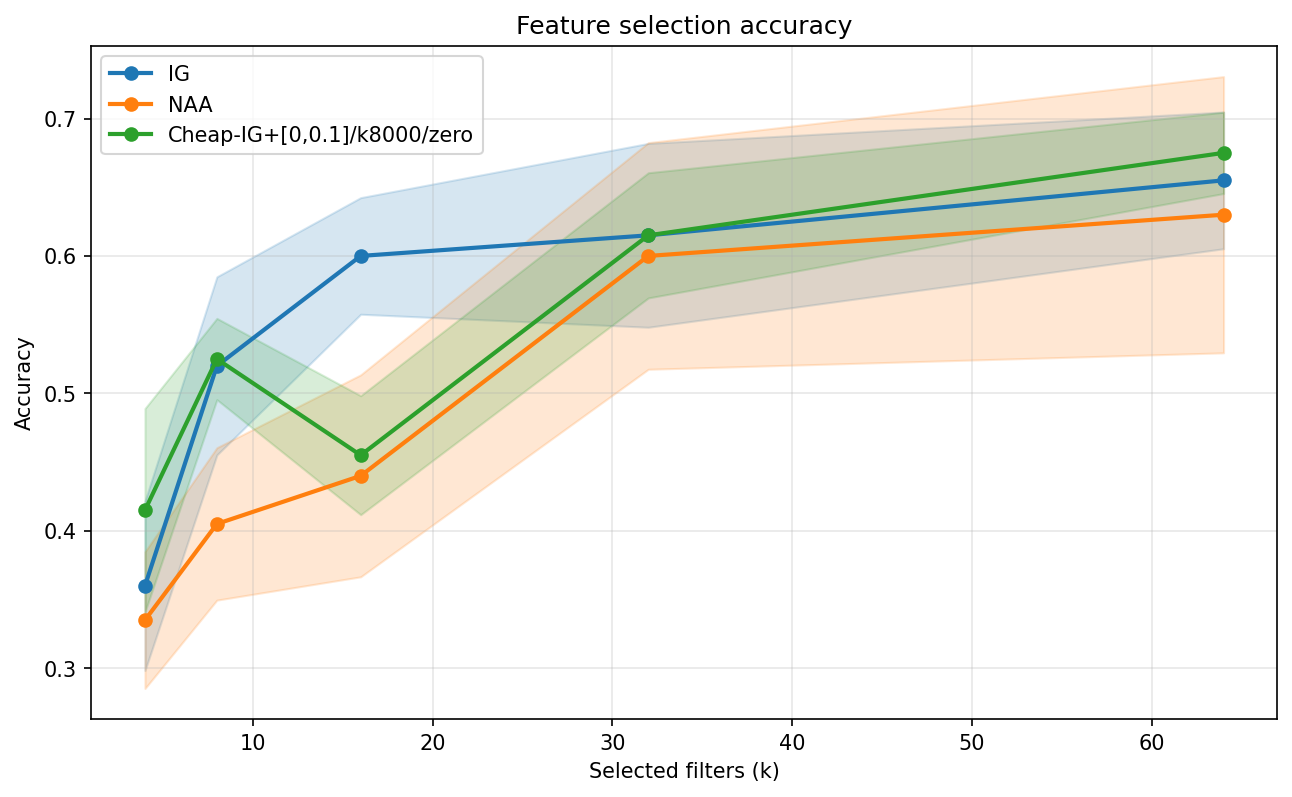

### Mean Macro-F1 Curves

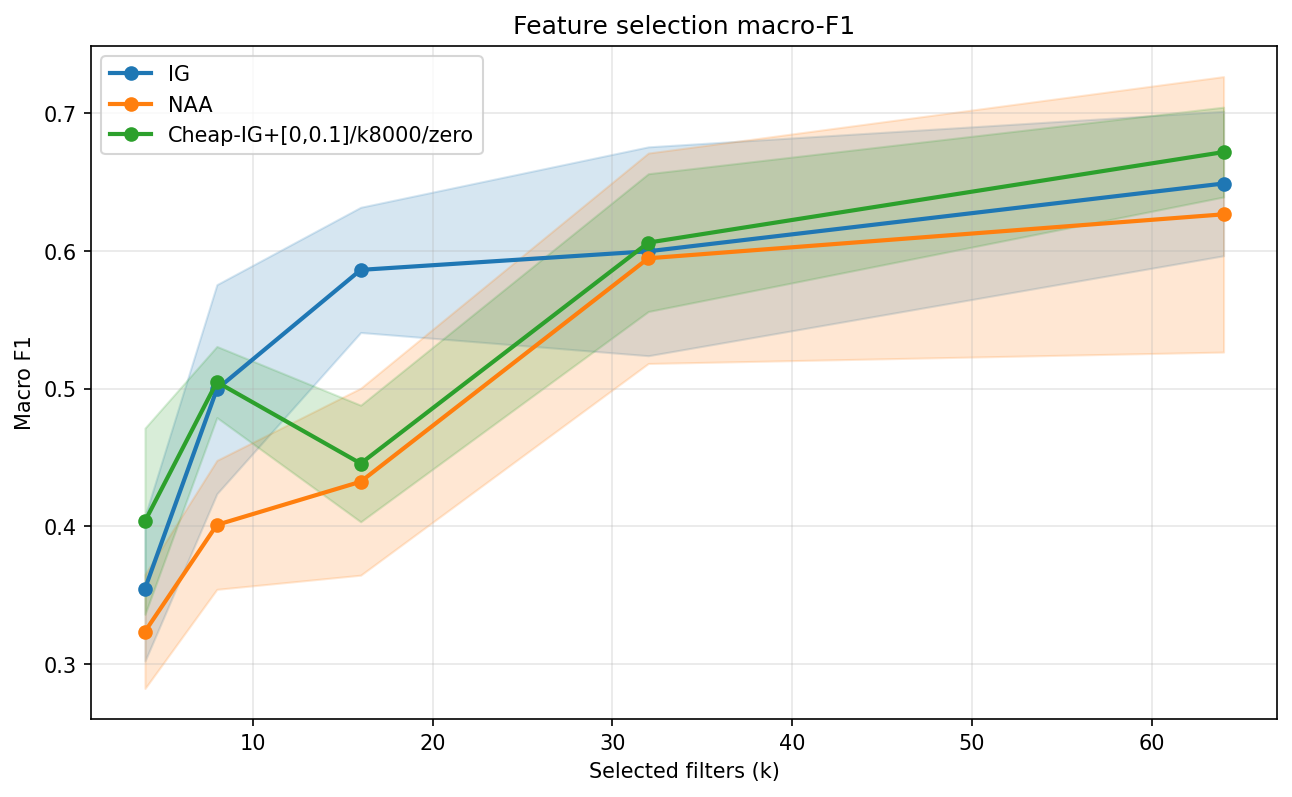

### Accuracy Heatmaps

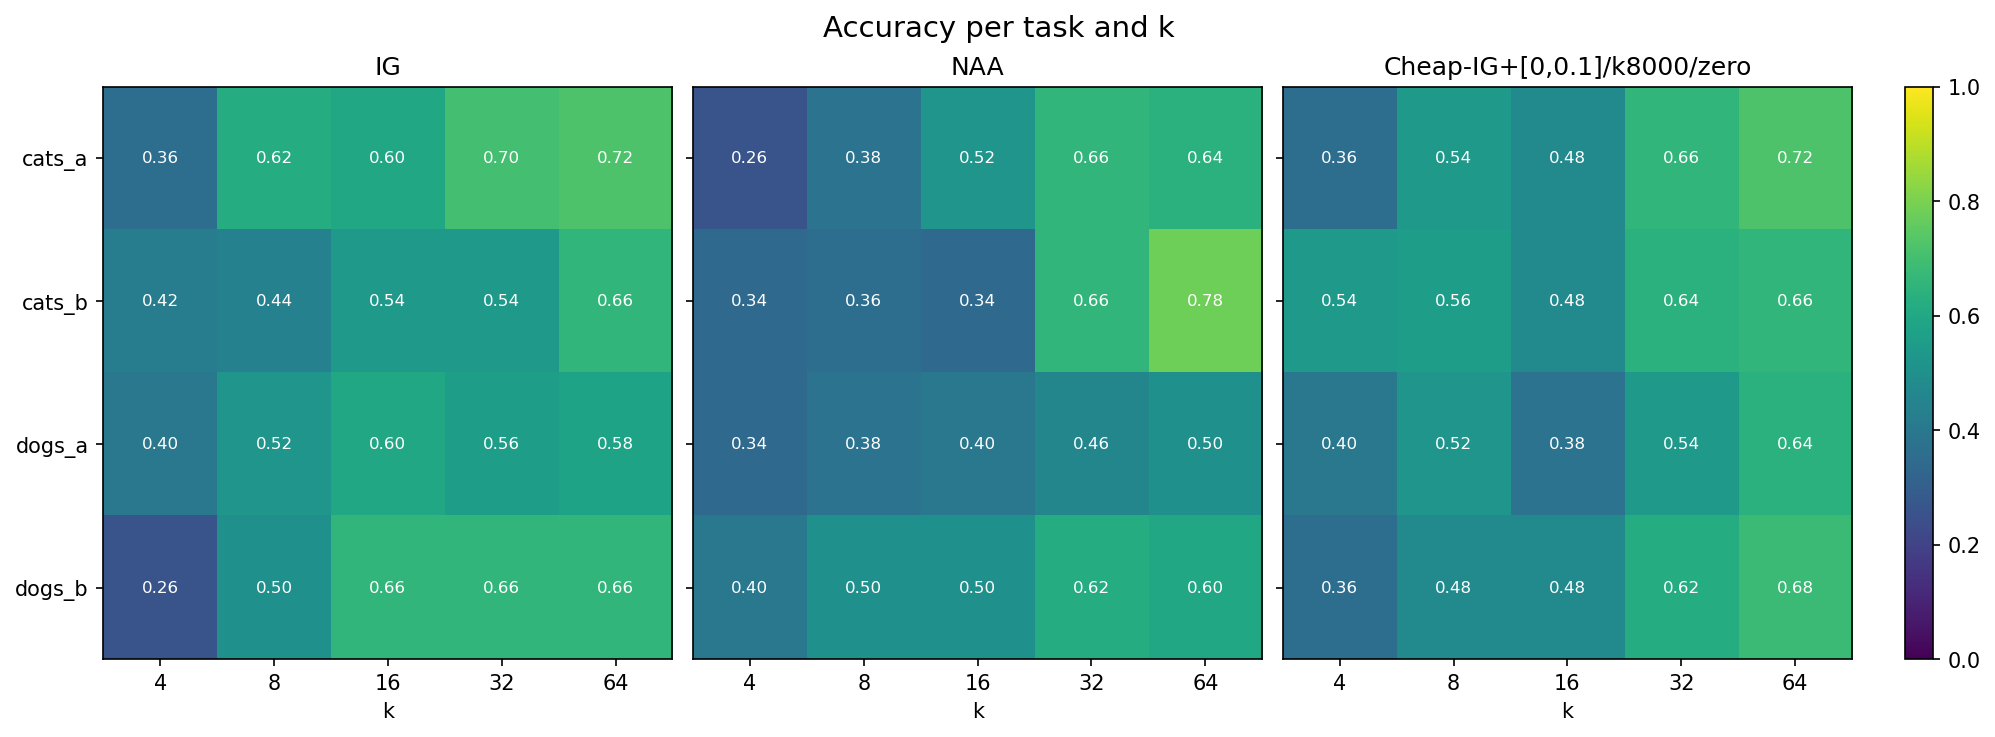

### Macro-F1 Heatmaps

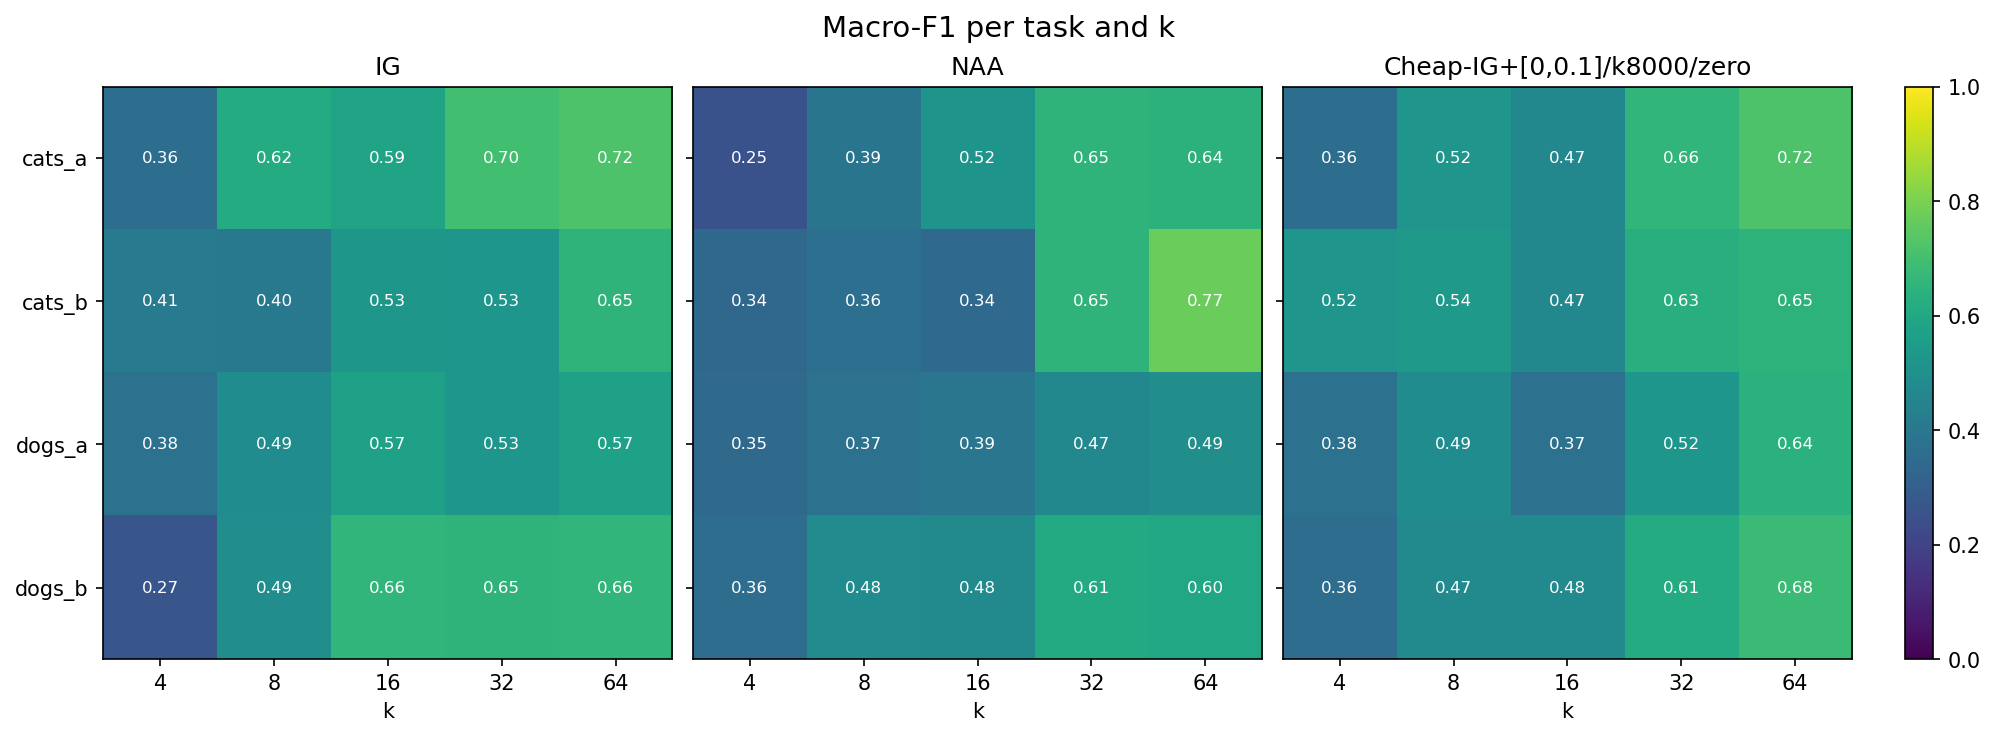

### Selected-Filter Overlap

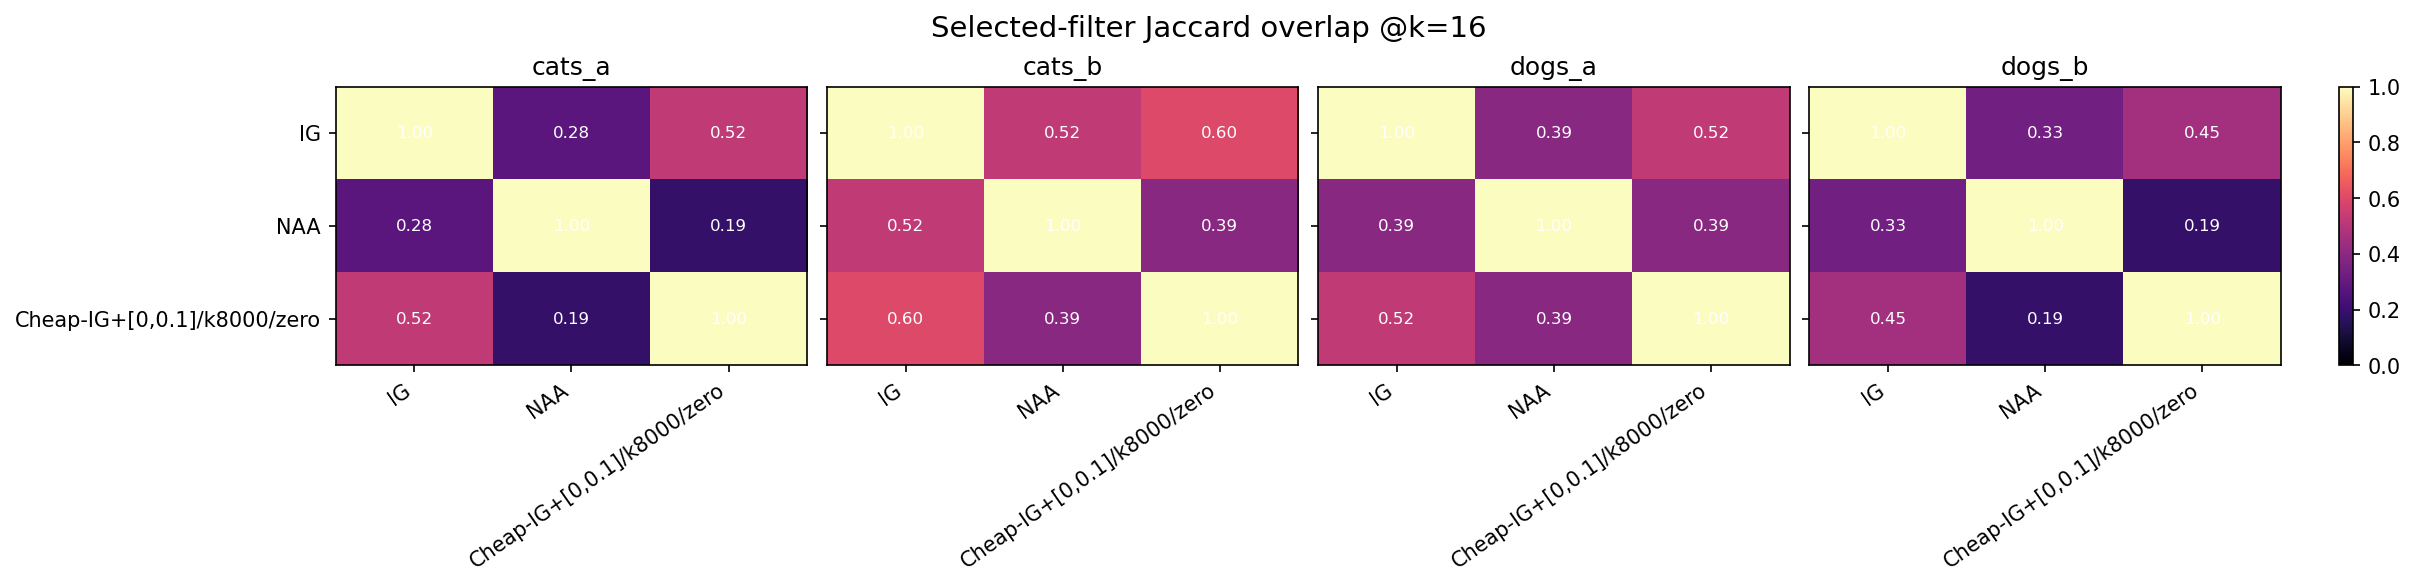

In [13]:
for key, title in [
    ("accuracy_curves", "Mean Accuracy Curves"),
    ("macro_f1_curves", "Mean Macro-F1 Curves"),
    ("accuracy_heatmaps", "Accuracy Heatmaps"),
    ("macro_f1_heatmaps", "Macro-F1 Heatmaps"),
    ("selected_overlap", "Selected-Filter Overlap"),
]:
    path = artifacts["figures"].get(key)
    if not path:
        continue
    display(Markdown(f"### {title}"))
    display(Image(filename=str(path)))
